# MSPR ObRail — Cadrage, problématiques et EDA

Ce notebook constitue le **document principal de cadrage** du projet.
Il présente le contexte, les problématiques retenues, les scénarios métier,
l'exploration des données, le nettoyage léger, la création de variables et les visualisations utiles.


## 1. Contexte du projet

ObRail cherche à exploiter des données de trajets ferroviaires européens pour répondre à deux besoins crédibles dans un rendu MSPR :

1. **Estimer les émissions futures** d'un trajet en fonction de ses caractéristiques et d'un scénario d'amélioration.
2. **Identifier les trajets à prioriser** dans une stratégie de décarbonation.

L'objectif n'est pas de produire une plateforme industrielle, mais un rendu **simple, lisible, pédagogique et défendable à l'oral**.


## 2. Problématiques retenues

### Problématique 1 — Régression
**Comment estimer les émissions futures d'un trajet ferroviaire (`future_kgco2`) à partir de ses variables opérationnelles et d'un scénario métier ?**

### Problématique 2 — Classification
**Comment repérer automatiquement les trajets à traiter en priorité (`priority_decarbonation`) parmi l'ensemble des trajets simulés ?**

### Pourquoi ces deux problématiques ?
- elles sont cohérentes avec les données disponibles ;
- elles permettent de montrer deux familles de modèles ;
- elles restent compréhensibles pour un correcteur ;
- elles donnent des livrables concrets : comparaison de scénarios, classement de trajets, modèles `.pkl`.


## 3. Scénarios métier étudiés

Quatre scénarios sont appliqués à chaque trajet :

- **reference** : aucune amélioration ;
- **optimise** : gains modérés sur l'énergie et l'exploitation ;
- **renforce** : gains plus marqués et baisse plus forte du diesel ;
- **ambitieux** : scénario volontariste avec électrification et gains de performance plus élevés.

Ces scénarios sont des **hypothèses métier simplifiées** servant à construire un cas d'usage pédagogique.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'raw' / 'eu_trips_v2.csv'
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DIESEL_CO2_FACTOR = 2.68
SCENARIOS = {
    'reference': {'energy_reduction': 0.00, 'grid_reduction': 0.00, 'diesel_reduction': 0.00, 'duration_reduction': 0.00, 'electrification_share': 0.00, 'service_gain': 0.00},
    'optimise': {'energy_reduction': 0.08, 'grid_reduction': 0.05, 'diesel_reduction': 0.10, 'duration_reduction': 0.03, 'electrification_share': 0.10, 'service_gain': 0.05},
    'renforce': {'energy_reduction': 0.15, 'grid_reduction': 0.15, 'diesel_reduction': 0.22, 'duration_reduction': 0.07, 'electrification_share': 0.25, 'service_gain': 0.10},
    'ambitieux': {'energy_reduction': 0.22, 'grid_reduction': 0.30, 'diesel_reduction': 0.35, 'duration_reduction': 0.12, 'electrification_share': 0.45, 'service_gain': 0.18},
}


## 4. Chargement et aperçu du jeu de données


In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dimensions du dataset brut : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions du dataset brut : 142,420 lignes × 25 colonnes


,arrival_minutes,departure_minutes,destination_stop_id,destination_stop_lat,destination_stop_lon,destination_stop_name,duration_minutes,n_stops,origin_stop_id,origin_stop_lat,origin_stop_lon,origin_stop_name,route_id,route_long_name,route_type,service_id,trip_id,country,distance_km,type_train,consommation_energy,gco2_per_kwh,consommation_totale,kgCO2_emis,consommation_diesel
0,672.000,556.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,116.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,1,OCESN117756F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000
1,791.000,676.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,2,OCESN117758F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000
2,922.000,800.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,122.000,2.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,3,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000
3,911.000,796.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,4,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000
4,911.000,796.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,5,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000


## 5. Nettoyage minimal et préparation de base

Le nettoyage reste volontairement simple :
- conversion numérique des variables utiles ;
- gestion légère des valeurs manquantes ;
- harmonisation de `country` et `type_train`.


In [3]:
df = df_raw.copy()

numeric_cols = [
    'distance_km', 'duration_minutes', 'n_stops', 'route_type',
    'departure_minutes', 'arrival_minutes', 'gco2_per_kwh',
    'consommation_energy', 'consommation_totale', 'consommation_diesel'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

df['country'] = df['country'].fillna('FR')
df['type_train'] = df['type_train'].fillna('electric')

missing_summary = pd.DataFrame({
    'missing_count': df[numeric_cols + ['country', 'type_train']].isna().sum(),
})
missing_summary.T


,distance_km,duration_minutes,n_stops,route_type,departure_minutes,arrival_minutes,gco2_per_kwh,consommation_energy,consommation_totale,consommation_diesel,country,type_train
missing_count,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Variables métier et scénarisation

On construit ensuite des variables plus parlantes pour la modélisation :
- vitesse moyenne ;
- nombre d'arrêts par 100 km ;
- intensité des scénarios ;
- émissions actuelles et futures estimées.


In [4]:
def compute_current_emissions(frame: pd.DataFrame) -> pd.Series:
    electric = frame['consommation_totale'] * frame['gco2_per_kwh'] / 1000.0
    diesel = frame['consommation_diesel'] * DIESEL_CO2_FACTOR
    return electric.where(frame['type_train'].eq('electric'), diesel)


def make_scenario_frame(frame: pd.DataFrame, scenario_name: str, scenario: dict) -> pd.DataFrame:
    out = frame.copy()
    out['scenario'] = scenario_name
    out['avg_speed_kmh'] = out['distance_km'] / (out['duration_minutes'] / 60.0)
    out['avg_speed_kmh'] = out['avg_speed_kmh'].replace([np.inf, -np.inf], 0.0).fillna(0.0)
    out['stops_per_100km'] = (out['n_stops'] / out['distance_km'].replace(0, np.nan)) * 100.0
    out['stops_per_100km'] = out['stops_per_100km'].fillna(0.0)

    out['scenario_energy_reduction'] = scenario['energy_reduction']
    out['scenario_grid_reduction'] = scenario['grid_reduction']
    out['scenario_diesel_reduction'] = scenario['diesel_reduction']
    out['scenario_duration_reduction'] = scenario['duration_reduction']
    out['scenario_electrification_share'] = scenario['electrification_share']
    out['scenario_service_gain'] = scenario['service_gain']

    electric_future = (
        out['consommation_totale']
        * (1.0 - scenario['energy_reduction'])
        * out['gco2_per_kwh']
        * (1.0 - scenario['grid_reduction'])
        / 1000.0
    )
    diesel_base = out['consommation_diesel'] * (1.0 - scenario['diesel_reduction']) * DIESEL_CO2_FACTOR
    diesel_bonus = diesel_base * scenario['electrification_share'] * 0.35
    diesel_future = (diesel_base - diesel_bonus).clip(lower=0.0)

    out['current_kgco2'] = compute_current_emissions(out)
    out['future_kgco2'] = electric_future.where(out['type_train'].eq('electric'), diesel_future)
    return out


scenario_frames = [make_scenario_frame(df, name, params) for name, params in SCENARIOS.items()]
df_scenarios = pd.concat(scenario_frames, ignore_index=True)
threshold = float(df_scenarios['future_kgco2'].quantile(0.75))
df_scenarios['priority_decarbonation'] = (df_scenarios['future_kgco2'] >= threshold).astype(int)

print(f"Jeu scénarisé : {df_scenarios.shape[0]:,} lignes")
print(f"Seuil de priorité (75e percentile) : {threshold:.3f} kgCO2")
df_scenarios.head()


Jeu scénarisé : 569,680 lignes
Seuil de priorité (75e percentile) : 256.953 kgCO2


,arrival_minutes,departure_minutes,destination_stop_id,destination_stop_lat,destination_stop_lon,destination_stop_name,duration_minutes,n_stops,origin_stop_id,origin_stop_lat,origin_stop_lon,origin_stop_name,route_id,route_long_name,route_type,service_id,trip_id,country,distance_km,type_train,consommation_energy,gco2_per_kwh,consommation_totale,kgCO2_emis,consommation_diesel,scenario,avg_speed_kmh,stops_per_100km,scenario_energy_reduction,scenario_grid_reduction,scenario_diesel_reduction,scenario_duration_reduction,scenario_electrification_share,scenario_service_gain,current_kgco2,future_kgco2,priority_decarbonation
0,672.000,556.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,116.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,1,OCESN117756F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000,reference,90.129,5.739,0.000,0.000,0.000,0.000,0.000,0.000,75.624,75.624,0
1,791.000,676.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,2,OCESN117758F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000,reference,90.913,5.739,0.000,0.000,0.000,0.000,0.000,0.000,75.624,75.624,0
2,922.000,800.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,122.000,2.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,3,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000,reference,85.697,1.148,0.000,0.000,0.000,0.000,0.000,0.000,75.624,75.624,0
3,911.000,796.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,4,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000,reference,90.913,5.739,0.000,0.000,0.000,0.000,0.000,0.000,75.624,75.624,0
4,911.000,796.000,StopPoint:OCETrain TER-87713040,47.323,5.027,Dijon,115.000,10.000,StopPoint:OCETrain TER-87723197,45.761,4.859,Lyon Part Dieu,FR:Line::B10C45A0-C32C-4232-85F2-4BB81B810084:,Paris - Lyon P D,2,5,OCESN117760F1187_F:TER:FR:Line::B10C45A0-C32C-...,FR,174.250,electric,20.000,21.700,"3,485.000",75.624,0.000,reference,90.913,5.739,0.000,0.000,0.000,0.000,0.000,0.000,75.624,75.624,0


## 7. Exploration descriptive


In [5]:
df_scenarios[[
    'distance_km', 'duration_minutes', 'n_stops', 'avg_speed_kmh',
    'stops_per_100km', 'current_kgco2', 'future_kgco2'
]].describe().T


,count,mean,std,min,25%,50%,75%,max
distance_km,"569,680.000",99.629,142.411,20.004,29.581,48.109,85.026,937.920
duration_minutes,"569,680.000",95.367,82.310,0.000,52.000,70.000,104.000,"1,425.000"
n_stops,"569,680.000",14.155,9.517,2.000,7.000,12.000,18.000,202.000
avg_speed_kmh,"569,680.000",52.518,30.760,0.000,33.836,44.356,60.955,244.500
stops_per_100km,"569,680.000",34.349,36.647,0.304,10.543,24.678,43.658,621.144
current_kgco2,"569,680.000",322.307,532.036,8.742,122.476,196.557,322.356,"6,519.654"
future_kgco2,"569,680.000",252.785,431.070,4.773,90.091,153.124,256.953,"6,519.654"


In [6]:
summary = (
    df_scenarios.groupby('scenario', as_index=False)
    .agg(
        future_kgco2_mean=('future_kgco2', 'mean'),
        future_kgco2_median=('future_kgco2', 'median'),
        priority_rate=('priority_decarbonation', 'mean'),
        current_kgco2_mean=('current_kgco2', 'mean'),
    )
    .sort_values('future_kgco2_mean')
)
summary


,scenario,future_kgco2_mean,future_kgco2_median,priority_rate,current_kgco2_mean
0,ambitieux,176.170,107.639,0.133,322.307
3,renforce,231.610,141.053,0.209,322.307
1,optimise,281.053,171.436,0.296,322.307
2,reference,322.307,196.557,0.361,322.307


## 8. Visualisations utiles


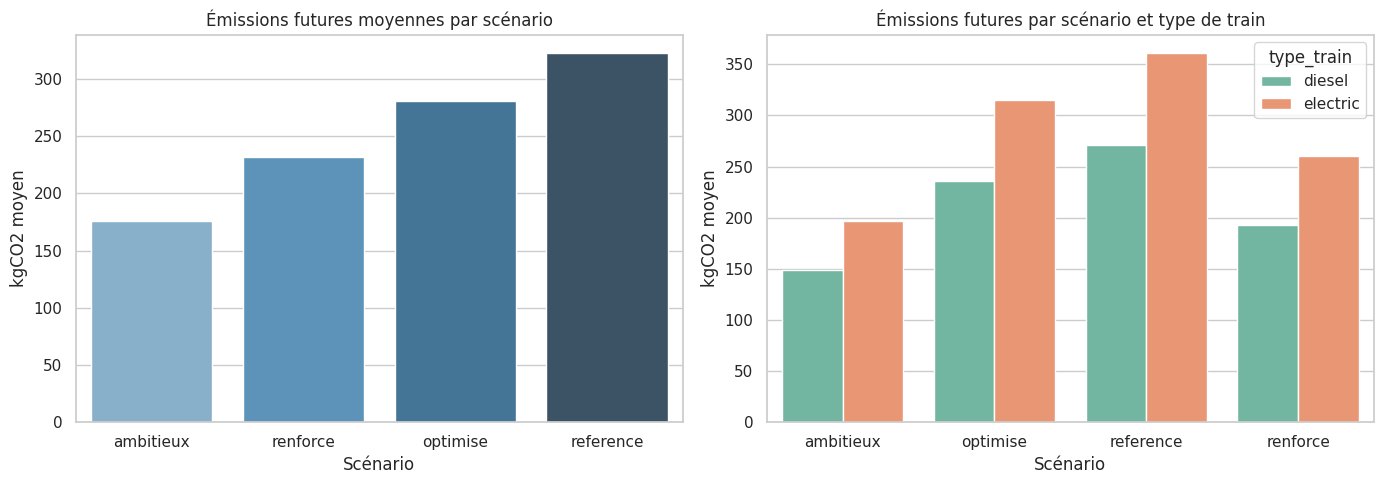

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='scenario', y='future_kgco2_mean', hue='scenario', legend=False, palette='Blues_d', ax=axes[0])
axes[0].set_title("Émissions futures moyennes par scénario")
axes[0].set_xlabel("Scénario")
axes[0].set_ylabel("kgCO2 moyen")

train_mix = (
    df_scenarios.groupby(['scenario', 'type_train'], as_index=False)['future_kgco2']
    .mean()
)
sns.barplot(data=train_mix, x='scenario', y='future_kgco2', hue='type_train', palette='Set2', ax=axes[1])
axes[1].set_title("Émissions futures par scénario et type de train")
axes[1].set_xlabel("Scénario")
axes[1].set_ylabel("kgCO2 moyen")

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'scenario_overview.png', dpi=160)
plt.show()


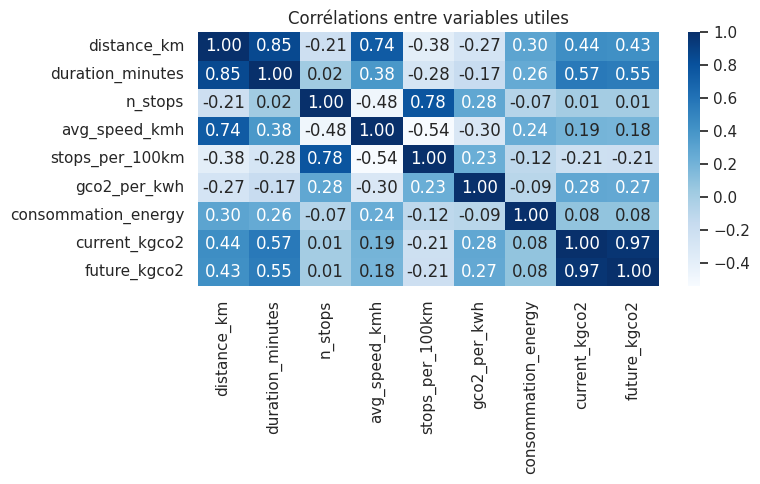

In [8]:
plt.figure(figsize=(8, 5))
corr_cols = [
    'distance_km', 'duration_minutes', 'n_stops', 'avg_speed_kmh',
    'stops_per_100km', 'gco2_per_kwh', 'consommation_energy',
    'current_kgco2', 'future_kgco2'
]
sns.heatmap(df_scenarios[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues', square=False)
plt.title("Corrélations entre variables utiles")
plt.tight_layout()
plt.show()


In [9]:
top_routes = df_scenarios.sort_values('future_kgco2', ascending=False)[[
    'origin_stop_name', 'destination_stop_name', 'country', 'scenario',
    'type_train', 'future_kgco2', 'priority_decarbonation'
]].head(15)
top_routes


,origin_stop_name,destination_stop_name,country,scenario,type_train,future_kgco2,priority_decarbonation
96793,Wien Hbf,Amersfoort Centraal,DE,reference,electric,"6,519.654",1
96809,Wien Hbf,Amersfoort Centraal,DE,reference,electric,"6,519.654",1
96857,Wien Hbf,Amersfoort Centraal,DE,reference,electric,"6,519.654",1
96782,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96824,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96846,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96844,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96813,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96830,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1
96821,Wien Hbf,Deventer,DE,reference,electric,"6,208.752",1


## 9. Features retenues pour la modélisation

Variables quantitatives :
- `distance_km`
- `duration_minutes`
- `n_stops`
- `route_type`
- `departure_minutes`
- `arrival_minutes`
- `avg_speed_kmh`
- `stops_per_100km`
- `gco2_per_kwh`
- `consommation_energy`
- variables numériques de scénario

Variables catégorielles :
- `country`
- `type_train`
- `scenario`


## 10. Lecture métier / scénarios d'usage

### Scénario A — Comparer des politiques d'amélioration
Comparer l'effet des scénarios sur un même portefeuille de trajets.

### Scénario B — Prioriser les trajets les plus émetteurs
Repérer les trajets à fort impact carbone pour cibler les investissements.

### Scénario C — Produire un support de décision simple
Disposer d'un notebook compréhensible, avec quelques graphiques lisibles, sans architecture lourde.


## 11. Conclusion du cadrage

Le notebook 00 montre que :
- les problématiques sont cohérentes avec les données ;
- la scénarisation métier permet de construire des cas d'usage crédibles ;
- les variables préparées sont suffisantes pour passer à une modélisation simple dans le notebook 01.
